# Server Performance Monitoring & Analytics

This project analyzes server log data to monitor infrastructure performance.

Pipeline:
CSV Dataset → Python Data Processing → SQL Storage → Power BI Dashboard

Metrics calculated:
- CPU Utilization
- Memory Usage
- Network Traffic
- Server Uptime

In [24]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt

In [25]:
df = pd.read_csv(r"C:\Data_Engineer_Use Case Analysis Assessment\Data\Sample_Data_Ingestion.csv")

df.head()

,Server_ID,Hostname,IP_Address,OS_Type,Server_Location,CPU_Utilization (%),Memory_Usage (%),Disk_IO (%),Network_Traffic_In (MB/s),Network_Traffic_Out (MB/s),Uptime (Hours),Downtime (Hours),Admin_Name,Admin_Email,Admin_Phone,Log_Timestamp
0,536c9e75-40a1-4a74-8ca6-c6abaec13999,srv-web02,100.33.3.46,Windows Server 2022,"Berlin, Germany",28.10,88.60,28.36,31.13,52.54,18.49,5.51,John Duarte,laurasolomon@example.net,+77 1834560143,11-03-2025 16:45
1,26bae71d-c025-4082-9484-ef7aa9e04836,srv-web02,249.168.171.15,Ubuntu 20.04,"London, UK",49.72,84.35,73.89,123.34,97.10,19.71,4.29,Abigail Montgomery,sherripatterson@example.com,+10 3791349757,25-01-2025 10:59
2,454de38a-5961-490f-9d46-d20663a36baf,srv-backup02,248.247.52.48,Red Hat Enterprise Linux,"New York, USA",44.72,57.64,14.94,69.60,112.81,18.64,5.36,David Jones,veronicanavarro@example.net,+38 9503876034,29-01-2025 08:31
3,8b8a3f40-1b67-4fe6-a65e-93fd07f317f7,srv-web02,87.221.187.138,Red Hat Enterprise Linux,"New York, USA",37.69,97.97,71.46,62.97,148.51,18.14,5.86,Dominic Richards,frankdawson@example.org,+93 2330701744,01-03-2025 16:49
4,375cb3db-89d3-4705-af4a-8f829cce1928,srv-app02,168.8.91.217,Windows Server 2022,"Tokyo, Japan",63.97,67.31,96.46,45.33,131.50,22.78,1.22,Paul Edwards,hgibson@example.com,+29 9075330226,21-02-2025 11:02


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Server_ID                   200 non-null    object 
 1   Hostname                    200 non-null    object 
 2   IP_Address                  200 non-null    object 
 3   OS_Type                     200 non-null    object 
 4   Server_Location             200 non-null    object 
 5   CPU_Utilization (%)         200 non-null    float64
 6   Memory_Usage (%)            200 non-null    float64
 7   Disk_IO (%)                 200 non-null    float64
 8   Network_Traffic_In (MB/s)   200 non-null    float64
 9   Network_Traffic_Out (MB/s)  200 non-null    float64
 10  Uptime (Hours)              200 non-null    float64
 11  Downtime (Hours)            200 non-null    float64
 12  Admin_Name                  200 non-null    object 
 13  Admin_Email                 200 non

In [27]:
df.describe()

,CPU_Utilization (%),Memory_Usage (%),Disk_IO (%),Network_Traffic_In (MB/s),Network_Traffic_Out (MB/s),Uptime (Hours),Downtime (Hours)
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,57.303850,60.142550,55.179150,78.116650,79.728800,20.612150,3.387850
std,25.590557,24.139824,26.267816,40.210749,40.401318,1.521107,1.521107
min,10.570000,20.030000,10.090000,10.330000,10.240000,18.010000,1.010000
25%,36.287500,38.920000,31.667500,45.065000,45.207500,19.185000,2.057500
50%,57.040000,60.075000,58.440000,78.935000,80.950000,20.865000,3.135000
75%,80.370000,81.412500,76.812500,113.760000,116.290000,21.942500,4.815000
max,99.300000,99.920000,99.650000,149.660000,149.250000,22.990000,5.990000


In [28]:
df.isnull().sum()

Server_ID                     0
Hostname                      0
IP_Address                    0
OS_Type                       0
Server_Location               0
CPU_Utilization (%)           0
Memory_Usage (%)              0
Disk_IO (%)                   0
Network_Traffic_In (MB/s)     0
Network_Traffic_Out (MB/s)    0
Uptime (Hours)                0
Downtime (Hours)              0
Admin_Name                    0
Admin_Email                   0
Admin_Phone                   0
Log_Timestamp                 0
dtype: int64

In [29]:
df = df.drop_duplicates()

In [44]:
df['Log_Timestamp'] = pd.to_datetime(
    df['Log_Timestamp'],
    format='%d-%m-%Y %H:%M',
    errors='coerce'
)

In [31]:
df['CPU_Status'] = df['CPU_Utilization (%)'].apply(
    lambda x: 'High Load' if x > 80 else 'Normal'
)

In [32]:
df['Memory_Status'] = df['Memory_Usage (%)'].apply(
    lambda x: 'High Usage' if x > 80 else 'Normal'
)

In [33]:
df['Total_Network_Traffic'] = (
    df['Network_Traffic_In (MB/s)'] +
    df['Network_Traffic_Out (MB/s)']
)

In [45]:
df['Total_Time'] = df['Uptime (Hours)'] + df['Downtime (Hours)']

df['Uptime_Percentage'] = (
    df['Uptime (Hours)'] / df['Total_Time'].replace(0, np.nan)
) * 100

In [35]:
def instance_size(cpu):
    
    if cpu < 40:
        return "Small"
    
    elif cpu < 70:
        return "Medium"
    
    else:
        return "Large"

df['Instance_Size'] = df['CPU_Utilization (%)'].apply(instance_size)

In [36]:
df.head()

,Server_ID,Hostname,IP_Address,OS_Type,Server_Location,CPU_Utilization (%),Memory_Usage (%),Disk_IO (%),Network_Traffic_In (MB/s),Network_Traffic_Out (MB/s),...,Admin_Name,Admin_Email,Admin_Phone,Log_Timestamp,CPU_Status,Memory_Status,Total_Network_Traffic,Total_Time,Uptime_Percentage,Instance_Size
0,536c9e75-40a1-4a74-8ca6-c6abaec13999,srv-web02,100.33.3.46,Windows Server 2022,"Berlin, Germany",28.10,88.60,28.36,31.13,52.54,...,John Duarte,laurasolomon@example.net,+77 1834560143,2025-03-11 16:45:00,Normal,High Usage,83.67,24.0,77.041667,Small
1,26bae71d-c025-4082-9484-ef7aa9e04836,srv-web02,249.168.171.15,Ubuntu 20.04,"London, UK",49.72,84.35,73.89,123.34,97.10,...,Abigail Montgomery,sherripatterson@example.com,+10 3791349757,2025-01-25 10:59:00,Normal,High Usage,220.44,24.0,82.125000,Medium
2,454de38a-5961-490f-9d46-d20663a36baf,srv-backup02,248.247.52.48,Red Hat Enterprise Linux,"New York, USA",44.72,57.64,14.94,69.60,112.81,...,David Jones,veronicanavarro@example.net,+38 9503876034,2025-01-29 08:31:00,Normal,Normal,182.41,24.0,77.666667,Medium
3,8b8a3f40-1b67-4fe6-a65e-93fd07f317f7,srv-web02,87.221.187.138,Red Hat Enterprise Linux,"New York, USA",37.69,97.97,71.46,62.97,148.51,...,Dominic Richards,frankdawson@example.org,+93 2330701744,2025-03-01 16:49:00,Normal,High Usage,211.48,24.0,75.583333,Small
4,375cb3db-89d3-4705-af4a-8f829cce1928,srv-app02,168.8.91.217,Windows Server 2022,"Tokyo, Japan",63.97,67.31,96.46,45.33,131.50,...,Paul Edwards,hgibson@example.com,+29 9075330226,2025-02-21 11:02:00,Normal,Normal,176.83,24.0,94.916667,Medium


In [37]:
df['CPU_Utilization (%)'].mean()

57.303850000000004

In [38]:
df.groupby('Server_Location')['CPU_Utilization (%)'].mean()

Server_Location
Berlin, Germany      54.360256
London, UK           62.509535
New York, USA        56.966250
Sydney, Australia    51.552222
Tokyo, Japan         59.959048
Name: CPU_Utilization (%), dtype: float64

In [39]:
df.groupby('OS_Type')['Memory_Usage (%)'].mean()

OS_Type
CentOS 8                    58.499070
Red Hat Enterprise Linux    59.008913
Ubuntu 20.04                56.782195
Windows Server 2019         61.793143
Windows Server 2022         65.937429
Name: Memory_Usage (%), dtype: float64

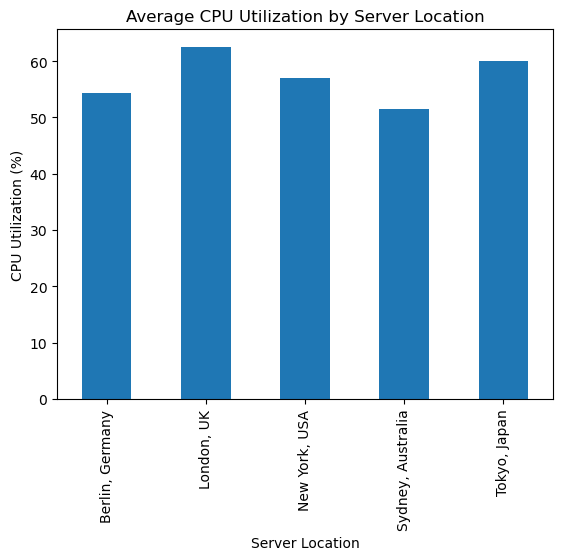

In [40]:
df.groupby('Server_Location')['CPU_Utilization (%)'].mean().plot(kind='bar')

plt.title("Average CPU Utilization by Server Location")
plt.xlabel("Server Location")
plt.ylabel("CPU Utilization (%)")

plt.show()

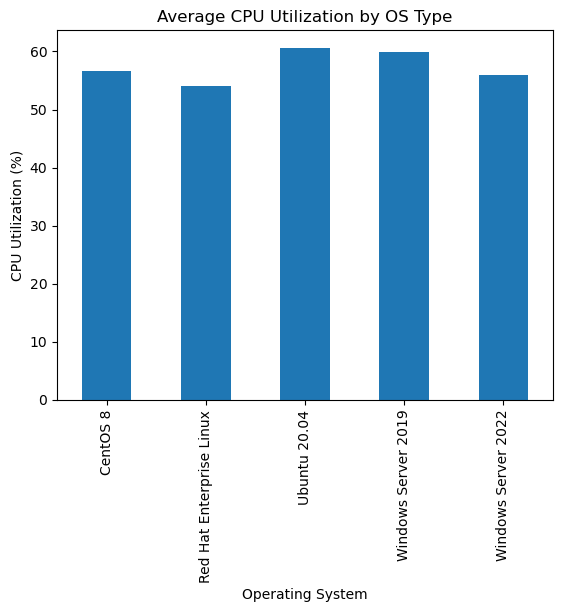

In [48]:
df.groupby('OS_Type')['CPU_Utilization (%)'].mean().plot(kind='bar')

plt.title("Average CPU Utilization by OS Type")
plt.xlabel("Operating System")
plt.ylabel("CPU Utilization (%)")
plt.show()

In [41]:
conn = sqlite3.connect("server_logs.db")

df.to_sql(
    "server_performance",
    conn,
    if_exists="replace",
    index=False
)

print("Data successfully stored in SQL database")

Data successfully stored in SQL database


In [42]:
query = "SELECT * FROM server_performance LIMIT 5"

pd.read_sql(query, conn)

,Server_ID,Hostname,IP_Address,OS_Type,Server_Location,CPU_Utilization (%),Memory_Usage (%),Disk_IO (%),Network_Traffic_In (MB/s),Network_Traffic_Out (MB/s),...,Admin_Name,Admin_Email,Admin_Phone,Log_Timestamp,CPU_Status,Memory_Status,Total_Network_Traffic,Total_Time,Uptime_Percentage,Instance_Size
0,536c9e75-40a1-4a74-8ca6-c6abaec13999,srv-web02,100.33.3.46,Windows Server 2022,"Berlin, Germany",28.10,88.60,28.36,31.13,52.54,...,John Duarte,laurasolomon@example.net,+77 1834560143,2025-03-11 16:45:00,Normal,High Usage,83.67,24.0,77.041667,Small
1,26bae71d-c025-4082-9484-ef7aa9e04836,srv-web02,249.168.171.15,Ubuntu 20.04,"London, UK",49.72,84.35,73.89,123.34,97.10,...,Abigail Montgomery,sherripatterson@example.com,+10 3791349757,2025-01-25 10:59:00,Normal,High Usage,220.44,24.0,82.125000,Medium
2,454de38a-5961-490f-9d46-d20663a36baf,srv-backup02,248.247.52.48,Red Hat Enterprise Linux,"New York, USA",44.72,57.64,14.94,69.60,112.81,...,David Jones,veronicanavarro@example.net,+38 9503876034,2025-01-29 08:31:00,Normal,Normal,182.41,24.0,77.666667,Medium
3,8b8a3f40-1b67-4fe6-a65e-93fd07f317f7,srv-web02,87.221.187.138,Red Hat Enterprise Linux,"New York, USA",37.69,97.97,71.46,62.97,148.51,...,Dominic Richards,frankdawson@example.org,+93 2330701744,2025-03-01 16:49:00,Normal,High Usage,211.48,24.0,75.583333,Small
4,375cb3db-89d3-4705-af4a-8f829cce1928,srv-app02,168.8.91.217,Windows Server 2022,"Tokyo, Japan",63.97,67.31,96.46,45.33,131.50,...,Paul Edwards,hgibson@example.com,+29 9075330226,2025-02-21 11:02:00,Normal,Normal,176.83,24.0,94.916667,Medium


In [47]:
df.to_csv("processed_server_logs.csv", index=False)
print("Pipeline completed successfully. Processed dataset ready for Power BI.")

Pipeline completed successfully. Processed dataset ready for Power BI.


## Conclusion

This project demonstrates a data analytics pipeline for monitoring server performance.

Key metrics analyzed:
- CPU utilization
- Memory usage
- Network traffic
- Server uptime percentage

The processed dataset can be integrated with Power BI to create an
interactive dashboard for monitoring server health and performance trends.